# Top

In [ ]:
import xarray as xr 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from dask.distributed import Client, LocalCluster

import sys
utils_path = './util_files/' # user changes
sys.path.append(utils_path)
import calculate_rho_w
import importlib
importlib.reload(calculate_rho_w)

<module 'calculate_rho_w' from '/localhome/phymku/WP5/WACCM-RR/utils/calculate_rho_w.py'>

In [30]:
mpl.rcParams['font.size'] = 15

In [ ]:
cluster = LocalCluster(n_workers=2,threads_per_worker=2,memory_limit='5Gib') # user changes
client = Client(cluster)

In [ ]:
path_in = '<path-to-reduced-data>/reduced_data/1D_timeseries/' # user changes

date = '2010-06' # user changes

ds_nonrr = xr.open_mfdataset(path_in + f'*_nonrr_*{date}*')
ds_rr = xr.open_mfdataset(path_in + f'*_rr_*{date}*')

In [12]:
ds_nonrr['w'] = calculate_rho_w.converta_omega_to_w(ds_nonrr['OMEGA'],ds_nonrr['T'], ds_nonrr.lev)
ds_rr['w'] = calculate_rho_w.converta_omega_to_w(ds_rr['OMEGA'],ds_rr['T'], ds_rr.lev)

In [58]:
ds1 = ds1.where((ds1.lat > 25) & (ds1.lat < 55) & (ds1.lon > 240) & (ds1.lon < 285)).isel(lev=slice(5,30)).dropna(dim='ncol')
ds2 = ds2.where((ds2.lat > 25) & (ds2.lat < 55) & (ds2.lon > 240) & (ds2.lon < 285)).isel(lev=slice(5,30)).dropna(dim='ncol')

In [15]:
ds1_w_plot = ds_nonrr['w'].var(dim='time')
ds2_w_plot = ds_rr['w'].var(dim='time')

In [16]:
ds1_T_plot = ds_nonrr['T'].var(dim='time')
ds2_T_plot = ds_rr['T'].var(dim='time')

In [34]:
ds1_w_plot = ds_nonrr['w'].var(dim=('ncol','time'))
ds2_w_plot = ds_rr['w'].var(dim=('ncol','time'))

In [19]:
ds1_T_var = ds_nonrr['T'].weighted(ds_nonrr['area']).var(dim=('ncol','time')).compute()
ds2_T_var = ds_rr['T'].weighted(ds_rr['area']).var(dim=('ncol','time')).compute()

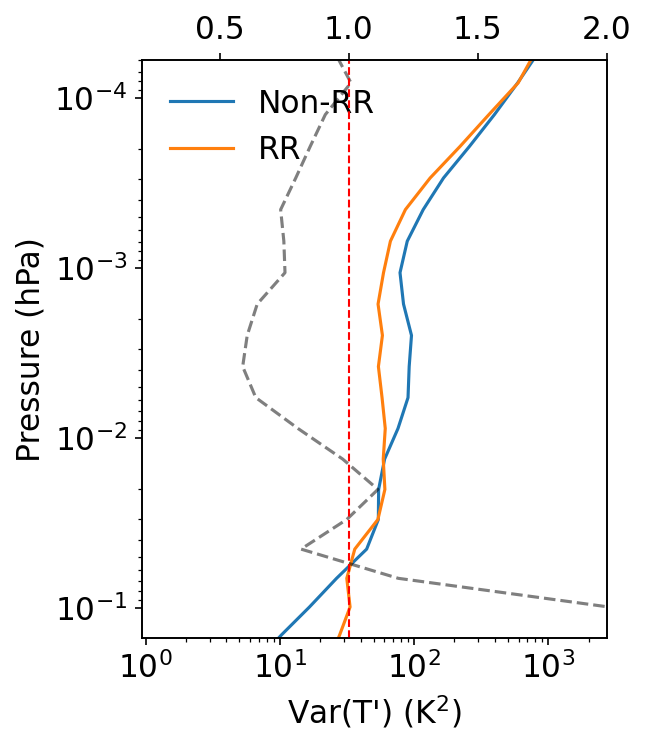

In [ ]:
plt.figure(figsize=(4,5),dpi=150)
ax1 = plt.gca()
ds1_T_plot.plot(ax=ax1, y='lev',label='Non-RR')
ds2_T_plot.plot(ax=ax1, y='lev',label='RR')

ax1.set_yscale('log')
ax1.set_ylim(1.5e-1,6e-5)
# ax1.set_xlim(0,3)
ax1.set_xscale('log')
ax1.set_ylabel('Pressure (hPa)')
ax1.tick_params(which='both')
ax1.set_xlabel("Var(T') (K$^2$)")
ax1.legend(frameon=False)


ax2 = ax1.twiny()

diff = ds2_T_var/ds1_T_var

diff.plot(y='lev',yscale='log',ax=ax2, c = 'k',alpha=0.5,linestyle='--',label='RR/Non-RR')
ax2.set_ylim(1.5e-1,6e-5)
ax2.set_xlim(0.2,2)
ax2.tick_params(which='both')
ax2.set_xlabel('')
ax2.axvline(1,linewidth=1,color='r',linestyle='--')

# plt.savefig('./varT_2010-06.png',bbox_inches='tight') 
plt.show()

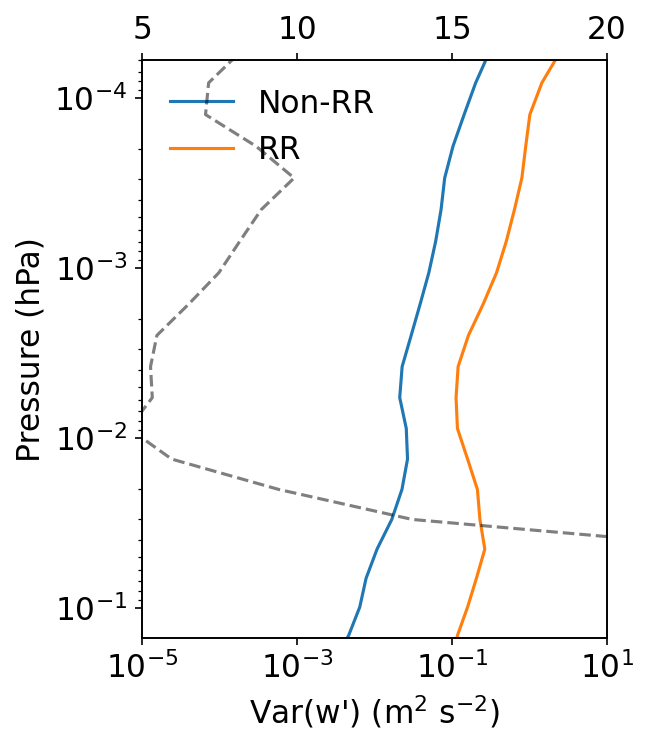

In [ ]:
plt.figure(figsize=(4,5),dpi=150)
ax1 = plt.gca()
ds1_w_plot.plot(ax=ax1, y='lev',label='Non-RR')
ds2_w_plot.plot(ax=ax1, y='lev',label='RR')

ax1.set_yscale('log')
ax1.set_ylim(1.5e-1,6e-5)
ax1.set_xlim(1e-5,1e1)
ax1.set_xscale('log')
ax1.set_ylabel('Pressure (hPa)')
ax1.set_xlabel("Var(w') (m$^2$ s$^{-2}$)")
ax1.tick_params(which='both')
ax1.legend(frameon=False)


ax2 = ax1.twiny()

diff = ds2_w_plot/ds1_w_plot
diff.plot(y='lev',yscale='log',ax=ax2, c = 'k',alpha=0.5,linestyle='--',label='RR/Non-RR')
ax2.set_ylim(1.5e-1,6e-5)
ax2.set_xlim(5,20)
ax2.set_xlabel('')
ax2.tick_params(which='both')

# plt.savefig('varw_2010-06.png',bbox_inches='tight')
plt.show()